# Clustering Pipeline Demo

Imports `clustering_pipeline.py` directly and runs it against synthetic data, so you can see the three output tables (`run`, `cluster_metrics`, `assignments`) without needing a real warehouse dataset.

Run this notebook from the `SCRIPTS` directory (its own directory) so the plain `import clustering_pipeline` below resolves.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from clustering_pipeline import ClusteringAlgorithm, ClusteringConfig, ClusteringPipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## 1. Synthetic dataset

Four Gaussian blobs in 5-D feature space, generated with `sklearn.datasets.make_blobs`. `cluster_std=1.8` gives the blobs enough overlap that density-based algorithms (DBSCAN/HDBSCAN) find some real noise points, so the noise/outlier columns aren't trivially empty. The pipeline standardizes features internally, so raw feature scale here doesn't matter.

In [2]:
N_SAMPLES = 1500
N_FEATURES = 5
N_CENTERS = 4
RANDOM_SEED = 42

features, true_labels = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    centers=N_CENTERS,
    cluster_std=1.8,
    random_state=RANDOM_SEED,
)

feature_columns = [f"feature_{i}" for i in range(N_FEATURES)]
df = pd.DataFrame(features, columns=feature_columns)
df.insert(0, "record_id", [f"rec-{i:05d}" for i in range(len(df))])

df.head()

,record_id,feature_0,feature_1,feature_2,feature_3,feature_4
0,rec-00000,-8.018141,-6.384898,2.619024,-0.043683,-1.917284
1,rec-00001,-5.986051,-9.675887,7.132816,6.782118,1.456105
2,rec-00002,-8.592642,8.411437,10.111055,-7.147525,-9.404030
3,rec-00003,0.249732,8.818518,5.362960,3.215429,-7.601824
4,rec-00004,-9.610066,-6.179846,5.221520,2.412496,2.186307


## 2. Run K-Means

`n_clusters` is required up front for K-Means, so it's set to the number of blobs we generated.

In [3]:
kmeans_config = ClusteringConfig(
    algorithm=ClusteringAlgorithm.KMEANS,
    model_name="demo-kmeans",
    model_id="mdl-demo-km-01",
    dataset_name="synthetic_blobs",
    dataset_version="v1",
    id_column="record_id",
    feature_columns=feature_columns,
    n_clusters=N_CENTERS,
    random_seed=RANDOM_SEED,
)
kmeans_result = ClusteringPipeline(kmeans_config).run(df)
kmeans_result.run

,uuid,model_name,model_id,clustering_timestamp,dataset_name,dataset_version,clustering_algorithm,distance_metric,model_backend,embedding_dimension,total_records,requested_cluster_count,actual_cluster_count,random_seed,clustering_time_ms,total_execution_time_ms,preprocessing_time_ms,inference_time_ms,silhouette_score,calinski_harabasz_score,davies_bouldin_score,dunn_index,intra_cluster_distance,inter_cluster_distance,min_cluster_size,max_cluster_size,mean_cluster_size,std_cluster_size,noise_points,noise_ratio_pct,outlier_count,outlier_ratio_pct,convergence_iterations,status,error_message,recommended_action
0,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:11.316338+00:00,synthetic_blobs,v1,kmeans,euclidean,scikit-learn,5,1500,4,4,42,3397.021,3553.4337,36.6103,3360.4107,0.540637,1848.409741,0.699514,2.627215,0.972928,3.215038,374,376,375.0,0.816497,0,0.0,59,3.93,3,SUCCESS,None,Promote as challenger model


In [4]:
kmeans_result.cluster_metrics

,uuid,run_uuid,model_name,model_id,clustering_timestamp,cluster_id,cluster_label,cluster_size,cluster_percentage,centroid,cluster_radius,intra_cluster_distance,nearest_cluster_distance,silhouette_score,min_distance,max_distance,mean_distance,std_distance,median_distance,p25_distance,p50_distance,p75_distance,p95_distance,p99_distance,outlier_count,outlier_percentage,representative_points,cluster_status,cluster_metadata
0,d78395bf-e1b7-4893-84ab-49ab31ef4885,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:11.316338+00:00,cluster_0,Cluster 0,374,24.93,"[1.223, 0.934, -0.0, 0.797, -0.736]",1.986012,1.921485,2.664802,0.530254,0.237760,1.986012,0.960742,0.346254,0.939486,0.720589,0.939486,1.213393,1.622639,1.837352,16,4.28,"[rec-01128, rec-00125, rec-01053]",STABLE,"{""member_count"": 374}"
1,1983911c-b43e-44bc-a930-af4dcbb87b22,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:11.316338+00:00,cluster_1,Cluster 1,376,25.07,"[-1.05, 0.967, 0.532, -1.353, -0.646]",2.053274,1.899159,2.977012,0.569612,0.233097,2.053274,0.949580,0.315277,0.912149,0.737915,0.912149,1.133256,1.523899,1.776108,12,3.19,"[rec-01321, rec-00189, rec-00846]",STABLE,"{""member_count"": 376}"
2,963a7083-fe4c-4fad-a710-3510c5148541,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:11.316338+00:00,cluster_2,Cluster 2,375,25.00,"[0.017, -0.648, -1.358, -0.2, -0.179]",2.089922,2.028613,2.664802,0.484732,0.109544,2.089922,1.014307,0.351213,0.997235,0.761292,0.997235,1.265117,1.598315,1.840154,13,3.47,"[rec-00019, rec-00970, rec-00143]",STABLE,"{""member_count"": 375}"
3,35749fb2-a24c-4592-9eb4-5893a7f2b502,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:11.316338+00:00,cluster_3,Cluster 3,375,25.00,"[-0.183, -1.253, 0.825, 0.761, 1.561]",2.001958,1.934169,3.020180,0.577845,0.204931,2.001958,0.967084,0.343410,0.933157,0.725339,0.933157,1.162129,1.629174,1.873560,18,4.80,"[rec-01378, rec-01422, rec-00709]",STABLE,"{""member_count"": 375}"


In [5]:
kmeans_result.assignments.head(10)

,uuid,run_uuid,model_name,model_id,assignment_timestamp,record_id,cluster_id,cluster_distance,cluster_probability,is_noise,is_outlier
0,c45f3bab-7a23-4206-b39c-24b65f5f1fb3,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00000,cluster_2,1.121907,0.583267,False,False
1,f2e7261c-592a-458e-97dc-472da4eae1e9,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00001,cluster_3,1.428023,0.751429,False,False
2,5a61a45f-05bb-4bc6-97c9-002c33867fd9,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00002,cluster_1,1.390552,0.810380,False,False
3,4454be22-1ef5-4568-9cda-eed71cb18be6,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00003,cluster_0,0.943930,0.845238,False,False
4,07613400-8ba2-4793-93d4-74b66dfdf480,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00004,cluster_3,1.215095,0.672018,False,False
5,283ae5a4-63ec-4a44-ba20-af12dd52c361,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00005,cluster_3,1.683849,0.731279,False,True
6,4ca8d94f-ec03-4286-a6fe-4c9313ed9c63,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00006,cluster_3,0.998126,0.779011,False,False
7,8943c91c-9d7b-4c1f-ac1f-ff0a15c9231f,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00007,cluster_3,1.607314,0.655502,False,False
8,f394c3ae-071c-4ae4-b255-2d097babcc0a,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00008,cluster_2,0.906980,0.615453,False,False
9,a448cedb-89f5-4ef7-9394-ddd06cc88ca2,867f1c4e-0f7b-4894-9657-ccf04d9e0266,demo-kmeans,mdl-demo-km-01,2026-09-04 07:35:14.899607+00:00,rec-00009,cluster_1,0.752967,0.832342,False,False


## 3. Visualize the K-Means assignments

The pipeline clusters on the full 5-D feature space; this projects down to 2 components with PCA purely so the result is plottable. Colors come from a fixed categorical order (never re-cycled per plot) so the same cluster keeps the same color across figures; noise is drawn in neutral gray since it isn't a real category.

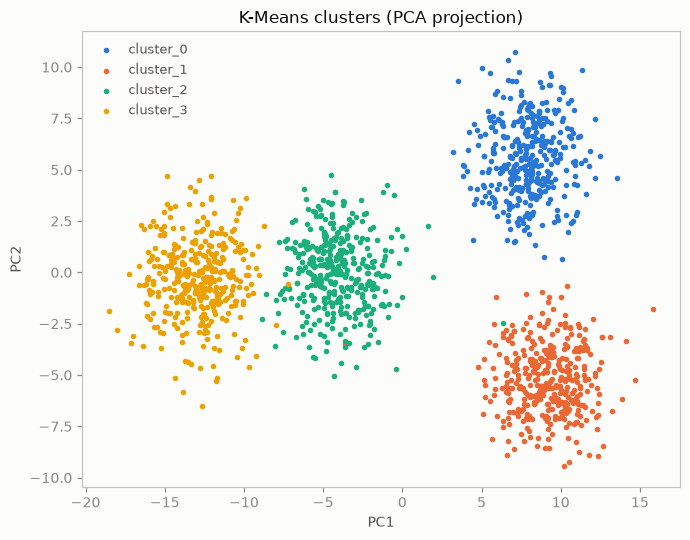

In [6]:
CATEGORICAL_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NOISE_COLOR = "#898781"


def plot_clusters(feature_df, assignments, feature_cols, title):
    """Scatter an assignment table's clusters on a 2-D PCA projection."""
    coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(feature_df[feature_cols])
    plot_df = assignments.copy()
    plot_df["pc1"] = coords[:, 0]
    plot_df["pc2"] = coords[:, 1]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    fig.patch.set_facecolor("#fcfcfb")
    ax.set_facecolor("#fcfcfb")

    real_cluster_ids = sorted(cid for cid in plot_df["cluster_id"].unique() if cid != "noise")
    for slot, cluster_id in enumerate(real_cluster_ids):
        subset = plot_df[plot_df["cluster_id"] == cluster_id]
        ax.scatter(
            subset["pc1"], subset["pc2"],
            s=16, linewidths=0,
            color=CATEGORICAL_PALETTE[slot % len(CATEGORICAL_PALETTE)],
            label=cluster_id,
        )

    noise = plot_df[plot_df["cluster_id"] == "noise"]
    if len(noise):
        ax.scatter(noise["pc1"], noise["pc2"], s=16, linewidths=0, color=NOISE_COLOR, label="noise")

    ax.set_title(title, color="#0b0b0b")
    ax.set_xlabel("PC1", color="#52514e")
    ax.set_ylabel("PC2", color="#52514e")
    ax.tick_params(colors="#898781")
    for spine in ax.spines.values():
        spine.set_color("#c3c2b7")
    ax.legend(frameon=False, labelcolor="#52514e", fontsize=9)
    fig.tight_layout()
    plt.show()


plot_clusters(df, kmeans_result.assignments, feature_columns, "K-Means clusters (PCA projection)")

## 4. Run DBSCAN

DBSCAN discovers its own cluster count, so `n_clusters` is left unset. `eps`/`min_samples` are tuned (via `algorithm_params`) for this standardized 5-D dataset; on real data these need retuning.

In [7]:
dbscan_config = ClusteringConfig(
    algorithm=ClusteringAlgorithm.DBSCAN,
    model_name="demo-dbscan",
    model_id="mdl-demo-db-01",
    dataset_name="synthetic_blobs",
    dataset_version="v1",
    id_column="record_id",
    feature_columns=feature_columns,
    random_seed=RANDOM_SEED,
    algorithm_params={"eps": 0.7, "min_samples": 10},
)
dbscan_result = ClusteringPipeline(dbscan_config).run(df)
dbscan_result.run

,uuid,model_name,model_id,clustering_timestamp,dataset_name,dataset_version,clustering_algorithm,distance_metric,model_backend,embedding_dimension,total_records,requested_cluster_count,actual_cluster_count,random_seed,clustering_time_ms,total_execution_time_ms,preprocessing_time_ms,inference_time_ms,silhouette_score,calinski_harabasz_score,davies_bouldin_score,dunn_index,intra_cluster_distance,inter_cluster_distance,min_cluster_size,max_cluster_size,mean_cluster_size,std_cluster_size,noise_points,noise_ratio_pct,outlier_count,outlier_ratio_pct,convergence_iterations,status,error_message,recommended_action
0,7f02bc79-18af-4d8b-8d63-3fe6937f05e6,demo-dbscan,mdl-demo-db-01,2026-09-04 07:35:16.710349+00:00,synthetic_blobs,v1,dbscan,euclidean,scikit-learn,5,1500,0,4,42,64.5922,237.416,8.8611,55.7311,0.557097,1944.897811,0.67159,2.74113,0.936142,3.221452,354,364,357.75,4.5,69,4.6,33,2.2,1,SUCCESS,None,Promote as challenger model


In [8]:
# includes the extra "noise" row alongside the real clusters
dbscan_result.cluster_metrics

,uuid,run_uuid,model_name,model_id,clustering_timestamp,cluster_id,cluster_label,cluster_size,cluster_percentage,centroid,cluster_radius,intra_cluster_distance,nearest_cluster_distance,silhouette_score,min_distance,max_distance,mean_distance,std_distance,median_distance,p25_distance,p50_distance,p75_distance,p95_distance,p99_distance,outlier_count,outlier_percentage,representative_points,cluster_status,cluster_metadata
0,dfd3ff59-0123-463c-b9db-c362ffac196f,7f02bc79-18af-4d8b-8d63-3fe6937f05e6,demo-dbscan,mdl-demo-db-01,2026-09-04 07:35:16.710349+00:00,cluster_0,Cluster 0,355,23.67,"[0.005, -0.653, -1.356, -0.179, -0.182]",1.744320,1.947144,2.668687,0.504376,0.093137,1.744320,0.973572,0.313682,0.970836,0.749418,0.970836,1.206356,1.507936,1.605291,5,1.41,"[rec-00019, rec-00970, rec-01088]",STABLE,"{""member_count"": 355}"
1,2e73ae9d-f4b1-438e-b658-6a61f8e0f165,7f02bc79-18af-4d8b-8d63-3fe6937f05e6,demo-dbscan,mdl-demo-db-01,2026-09-04 07:35:16.710349+00:00,cluster_1,Cluster 1,358,23.87,"[1.235, 0.93, 0.001, 0.793, -0.742]",1.726998,1.848609,2.668687,0.546869,0.230613,1.726998,0.924304,0.306754,0.915306,0.702317,0.915306,1.161499,1.410801,1.565731,4,1.12,"[rec-01128, rec-00125, rec-01053]",STABLE,"{""member_count"": 358}"
2,7e11e543-ac37-4e29-be81-202a1bb7b750,7f02bc79-18af-4d8b-8d63-3fe6937f05e6,demo-dbscan,mdl-demo-db-01,2026-09-04 07:35:16.710349+00:00,cluster_2,Cluster 2,354,23.60,"[-0.174, -1.257, 0.816, 0.778, 1.556]",1.710056,1.842070,3.008576,0.595527,0.200819,1.710056,0.921035,0.292825,0.908756,0.716305,0.908756,1.105991,1.440341,1.622627,12,3.39,"[rec-01378, rec-01422, rec-00709]",STABLE,"{""member_count"": 354}"
3,0026681f-6ad1-4688-8b8f-a535d7aa42f0,7f02bc79-18af-4d8b-8d63-3fe6937f05e6,demo-dbscan,mdl-demo-db-01,2026-09-04 07:35:16.710349+00:00,cluster_3,Cluster 3,364,24.27,"[-1.065, 0.971, 0.541, -1.35, -0.647]",1.807491,1.851315,2.994244,0.581200,0.230103,1.807491,0.925658,0.290936,0.908407,0.728645,0.908407,1.118159,1.444057,1.593791,12,3.30,"[rec-01321, rec-00189, rec-00846]",STABLE,"{""member_count"": 364}"
4,6a5e0025-9309-4ca9-a2f8-a5531cc8a88b,7f02bc79-18af-4d8b-8d63-3fe6937f05e6,demo-dbscan,mdl-demo-db-01,2026-09-04 07:35:16.710349+00:00,noise,Noise,69,4.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69,100.00,"[rec-00014, rec-00048, rec-00069]",NOISE,"{""member_count"": 69}"


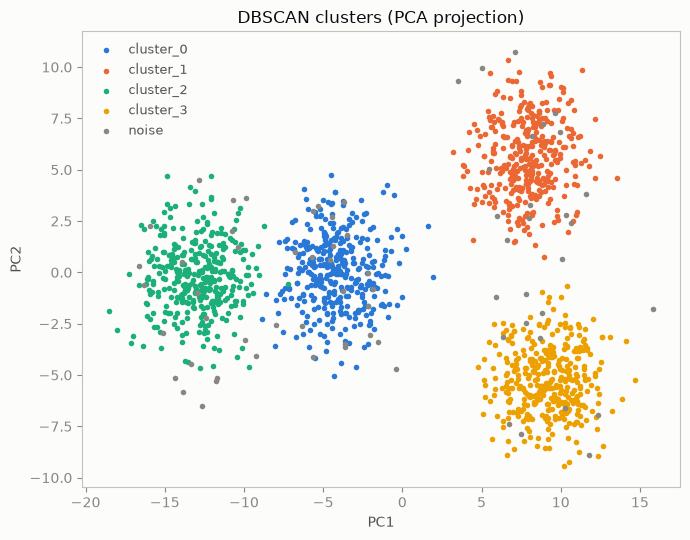

In [9]:
plot_clusters(df, dbscan_result.assignments, feature_columns, "DBSCAN clusters (PCA projection)")

## 5. Compare all six algorithms

Runs every supported algorithm against the same dataset with reasonable defaults and lines up their run-level quality metrics side by side.

In [10]:
algorithm_configs = {
    ClusteringAlgorithm.KMEANS: {"n_clusters": N_CENTERS},
    ClusteringAlgorithm.MINIBATCH_KMEANS: {"n_clusters": N_CENTERS},
    ClusteringAlgorithm.DBSCAN: {"algorithm_params": {"eps": 0.7, "min_samples": 10}},
    ClusteringAlgorithm.HDBSCAN: {"algorithm_params": {"min_cluster_size": 15}},
    ClusteringAlgorithm.GMM: {"n_clusters": N_CENTERS},
    ClusteringAlgorithm.AGGLOMERATIVE: {"n_clusters": N_CENTERS},
}

comparison_rows = []
for algorithm, extra_kwargs in algorithm_configs.items():
    config = ClusteringConfig(
        algorithm=algorithm,
        model_name=f"demo-{algorithm.value}",
        model_id=f"mdl-demo-{algorithm.value}-01",
        dataset_name="synthetic_blobs",
        dataset_version="v1",
        id_column="record_id",
        feature_columns=feature_columns,
        random_seed=RANDOM_SEED,
        **extra_kwargs,
    )
    result = ClusteringPipeline(config).run(df)
    comparison_rows.append(result.run.iloc[0])

comparison = pd.DataFrame(comparison_rows)
comparison[[
    "clustering_algorithm", "actual_cluster_count", "noise_points", "outlier_count",
    "silhouette_score", "calinski_harabasz_score", "davies_bouldin_score", "dunn_index",
    "status", "recommended_action",
]]

C:\Users\BishwajitPrasadGond\AppData\Roaming\Python\Python314\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,clustering_algorithm,actual_cluster_count,noise_points,outlier_count,silhouette_score,calinski_harabasz_score,davies_bouldin_score,dunn_index,status,recommended_action
0,kmeans,4,0,59,0.540637,1848.409741,0.699514,2.627215,SUCCESS,Promote as challenger model
0,minibatch_kmeans,4,0,62,0.540637,1848.409741,0.699514,2.622577,SUCCESS,Promote as challenger model
0,dbscan,4,69,33,0.557097,1944.897811,0.671590,2.741130,SUCCESS,Promote as challenger model
0,hdbscan,4,218,14,0.585780,2044.914978,0.620420,3.017414,SUCCESS,Tune density parameters (eps / min_samples / m...
0,gmm,4,0,59,0.540442,1846.509043,0.700283,2.622514,CONVERGED,Promote as challenger model
0,agglomerative,4,0,59,0.540442,1846.509043,0.700283,2.623437,SUCCESS,Promote as challenger model
